In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [2]:
df= pd.read_excel(r"C:\Users\HP\Downloads\real+estate+valuation+data+set\Real estate valuation data set.xlsx")
df

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.666667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250000,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000000,8.1,104.81010,5,24.96674,121.54067,52.5


## Dataset Information  

This dataset comes from the **Sindian District** of New Taipei City, Taiwan, and contains historical real estate valuation records.  

Each entry represents information about a house or apartment, along with surrounding factors that typically influence property prices such as age of the house, distance to the nearest MRT (metro) station, number of nearby convenience stores, and geographic coordinates (latitude & longitude).  

---

### Why This Dataset is Valuable
- It captures real-world housing market dynamic from an active urban district in Taiwan.  
- It includes both *structural features (like house age) and locational features (like transport and amenities).  
- It is relatively clean and small in size, making it a great starting point for experimentation with regression, feature engineering, and predictive modeling.  

---

### Source
Originally published in the **UCI Machine Learning Repository**:  
*Real estate valuation data set (New Taipei City, Taiwan)*

### Fixing the Transaction Date

One of the first things I noticed in this dataset is that the `X1 transaction date` column isn’t in a normal date format.  
Instead of something like “2012-12-01,” it shows numbers like `2012.9166667`.  
That’s basically the year plus a fraction that represents the month. For example:
- `2012.916...` → December 2012  
- `2013.083...` → February 2013  

Clearly, I can’t leave it like this if I want to analyze trends over time.  

My plan is to:
- Extract the year from the integer part.  
- Convert the decimal part into the month.  
- Combine them into a proper `transaction_date` column that pandas can recognize as a datetime.  

Once I have a proper date column, it’ll be much easier to work with.

---

### Creating Time-Based Features

After fixing the date, I want to go further and create some extra columns that capture time information.  
Some of the ideas I have are:
- **Quarter** (Q1–Q4) → because housing prices might show quarterly trends.  
- **Season** (Winter, Spring, Summer, Fall) → useful for spotting any seasonal patterns in the data.  

This should help me explore whether the timing of a transaction has any influence on house prices.

---

### Renaming Columns for Clarity

Another thing that stands out is how messy the column names are.  
They look like: `X2 house age`, `X3 distance to the nearest MRT station`, etc.  

Before I write any serious code, I plan to clean them up with shorter, clearer names like:
- `house_age`  
- `dist_to_mrt`  
- `n_convenience`  
- `latitude`  
- `longitude`  
- `price_per_unit_area`  

This way, when I eventually build models or write functions, the code will be more readable (and I’ll make fewer mistakes typing those long column names).

## Feature Description (Data Dictionary)

| Feature Name | Description | Type |
|--------------|-------------|------|
| **transaction_date** | The year and month when the property was sold. | Date/Time |
| **house_age** | Age of the house in years at the time of transaction. | Numeric |
| **dist_to_mrt** | Distance (in meters) to the nearest MRT (metro) station. | Numeric |
| **num_convenience** | Number of convenience stores within walking distance of the property. | Numeric |
| **latitude** | Latitude coordinate of the property location. | Numeric |
| **longitude** | Longitude coordinate of the property location. | Numeric |
| **house_price_unit_area** | Target variable — house price per unit area (measured in ping, where 1 ping ≈ 3.3 m²). | Numeric |



In [3]:
#Fixing transaction date column

df["Year"] = df["X1 transaction date"].astype(int)
df["Month"] = ((df["X1 transaction date"] - df["Year"]) * 12 + 1).round().astype(int)

df["transaction_date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)

In [4]:
#Extracting time features 
df["quarter"] = df["transaction_date"].dt.quarter
df["season"] = df["transaction_date"].dt.month % 12 // 3 + 1  # 1=Winter ... 4=Fall

In [5]:
#Renaming columns
df = df.rename(columns={
    "X2 house age": "house_age",
    "X3 distance to the nearest MRT station": "dist_to_mrt",
    "X4 number of convenience stores": "n_convenience",
    "X5 latitude": "latitude",
    "X6 longitude": "longitude",
    "Y house price of unit area": "price_per_unit_area"
})


## **Feature Engineering**

After cleaning up the time elements, the next step I’m planning is to make the dataset more useful for analysis and prediction.  
That’s where the feature engineering below comes in.

---

### Feature Engineering

1. **Log Transformations**
   - Some of the values in this dataset (like distance to MRT stations and house prices) vary a lot — some are very small while others are extremely large.  
   - To make things easier for the model I’ll build later, I plan to apply a **log transformation**:
     - `log_dist_to_mrt`: this will reduce the impact of very large distances so they don’t overshadow everything else.  
     - `log_price`: this will smooth out really high house prices compared to cheaper ones.  

   
2. **Age Buckets**
   - Instead of using `house_age` as a raw continuous variable, we grouped houses into meaningful categories:
     - **0 years** → brand new properties  
     - **1–10 years** → newer homes  
     - **10–20 years** → fairly new  
     - **20–40 years** → older homes  
     - **40–60 years** → very old properties  
     - **60+ years** → extremely old properties  
   - This approach makes sense because in real estate, a 3-year-old and an 8-year-old house are often treated the same by buyers, but comparing a 5-year-old with a 45-year-old house is very different.  
   - By grouping ages into buckets, we make the data easier to interpret

---

### Geographic Features

1. **Distance to City Center**
   - Since location is everything in real estate, I want to calculate how far each property is from Taipei city center (roughly at `25.0330, 121.5654`).  
   - This will give me a new feature: `dist_to_center` (in kilometers).  
   - The thinking here is straightforward and it is that homes closer to the center usually command higher prices.

2. **Neighborhood Clusters**
   - I also want to capture the idea of “neighborhoods.”  
   - By using KMeans clustering on the latitude and longitude, I can group the houses into about 5 clusters.  
   - Each cluster will roughly represent a neighborhood or district, even if we don’t have official labels.  
   - This should help the model capture local price differences that come from being in a certain area.

---

### Why I’m Doing This

For me, these transformations are about making the dataset smarter before I even start modeling:  
- They reduce noise from raw numbers.  
- They highlight relationships that actually matter in real estate (like location, house age, and accessibility).  
- They set up the predictive model to behave a bit more “human” in how it understands the housing market.  

At the end of the day, I want the dataset to “think” a little like a real estate agent 


In [6]:
!{sys.executable} -m pip install geopy

'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.


In [7]:
#Feature engineering 
df["log_dist_to_mrt"] = np.log1p(df["dist_to_mrt"])
df["log_price"] = np.log1p(df["price_per_unit_area"])
bins = [-0.1, 0.1, 10, 20, 40, 60, 100]
labels = ['0', '1-10', '10-20', '20-40', '40-60', '60+']
df['age_group'] = pd.cut(df['house_age'], bins=bins, labels=labels)


# 6. Geographic features
# Define Taipei city center (rough coordinates)
taipei_center = (25.0330, 121.5654)

from sklearn.cluster import KMeans
from geopy.distance import geodesic

# Computing distance to city center (km)
df["dist_to_center"] = df.apply(
    lambda row: geodesic((row["latitude"], row["longitude"]), taipei_center).km, axis=1
)

# Cluster neighborhoods using KMeans (say 5 clusters)
coords = df[["latitude", "longitude"]]
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["neighborhood_cluster"] = kmeans.fit_predict(coords)

# dropping the old raw transaction date if not needed
df = df.drop(columns=["X1 transaction date"])

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [8]:
df.head()

,No,house_age,dist_to_mrt,n_convenience,latitude,longitude,price_per_unit_area,Year,Month,transaction_date,quarter,season,log_dist_to_mrt,log_price,age_group,dist_to_center,neighborhood_cluster
0,1,32.0,84.87882,10,24.98298,121.54024,37.9,2012,12,2012-12-01,4,1,4.452937,3.660994,20-40,6.095201,3
1,2,19.5,306.59470,9,24.98034,121.53951,42.2,2012,12,2012-12-01,4,1,5.728783,3.765840,10-20,6.391996,3
2,3,13.3,561.98450,5,24.98746,121.54391,47.3,2013,8,2013-08-01,3,3,6.333252,3.877432,10-20,5.491231,3
3,4,13.3,561.98450,5,24.98746,121.54391,54.8,2013,7,2013-07-01,3,3,6.333252,4.021774,10-20,5.491231,3
4,5,5.0,390.56840,5,24.97937,121.54245,43.1,2012,11,2012-11-01,4,4,5.970160,3.786460,1-10,6.376489,3


# **Exploratory Data Analysis**

Now that the dataset has been cleaned up and enriched, below I want to take a closer look at what the data is actually saying.  
This is basically EDA stage where the structure of the data is to be understood, spotting patterns, and figuring out which factors seem to drive house prices in Taipei.  

In [9]:
# Basic dataset overview
print(df.shape)
print(df.info())
df.describe().T

(414, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   No                    414 non-null    int64         
 1   house_age             414 non-null    float64       
 2   dist_to_mrt           414 non-null    float64       
 3   n_convenience         414 non-null    int64         
 4   latitude              414 non-null    float64       
 5   longitude             414 non-null    float64       
 6   price_per_unit_area   414 non-null    float64       
 7   Year                  414 non-null    int32         
 8   Month                 414 non-null    int32         
 9   transaction_date      414 non-null    datetime64[ns]
 10  quarter               414 non-null    int64         
 11  season                414 non-null    int64         
 12  log_dist_to_mrt       414 non-null    float64       
 13  log_price 

,count,mean,std,min,25%,50%,75%,max
No,414.0,207.500000,119.655756,1.000000,104.250000,207.500000,310.750000,414.000000
house_age,414.0,17.712560,11.392485,0.000000,9.025000,16.100000,28.150000,43.800000
dist_to_mrt,414.0,1083.885689,1262.109595,23.382840,289.324800,492.231300,1454.279000,6488.021000
n_convenience,414.0,4.094203,2.945562,0.000000,1.000000,4.000000,6.000000,10.000000
latitude,414.0,24.969030,0.012410,24.932070,24.963000,24.971100,24.977455,25.014590
longitude,414.0,121.533361,0.015347,121.473530,121.528085,121.538630,121.543305,121.566270
price_per_unit_area,414.0,37.980193,13.606488,7.600000,27.700000,38.450000,46.600000,117.500000
Year,414.0,2012.695652,0.460687,2012.000000,2012.000000,2013.000000,2013.000000,2013.000000
Month,414.0,6.439614,3.381330,1.000000,4.000000,6.000000,9.000000,12.000000
quarter,414.0,2.466184,1.092597,1.000000,2.000000,2.000000,3.000000,4.000000


In [10]:
#Fixing data types
df = df.astype({'Year':'int64','Month':'int64','quarter':'int64','season':'int64','neighborhood_cluster':'int64', 'age_group':'category', 'n_convenience': 'int64'})

#removing row number column
df = df.drop(columns=["No"])

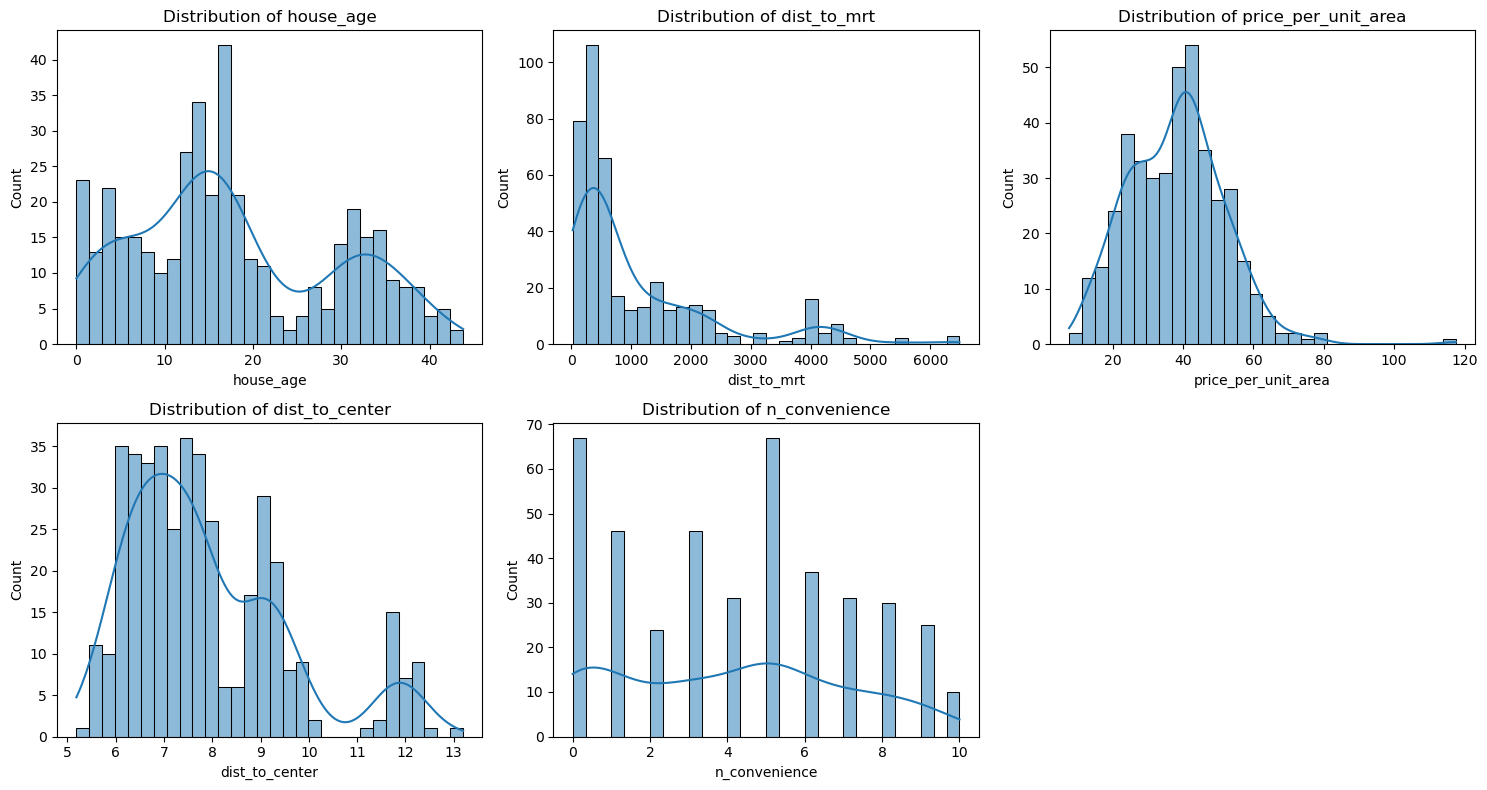

In [11]:
# Distribution plots for key numerical features
numeric_features = ["house_age", "dist_to_mrt", "price_per_unit_area", "dist_to_center", 'n_convenience']

plt.figure(figsize=(15,8))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

### Feature Relationships

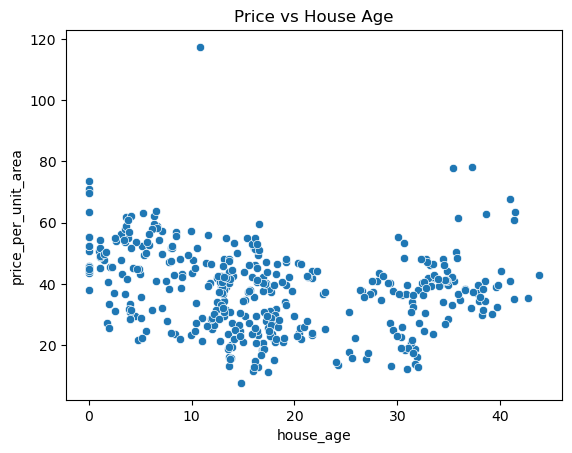

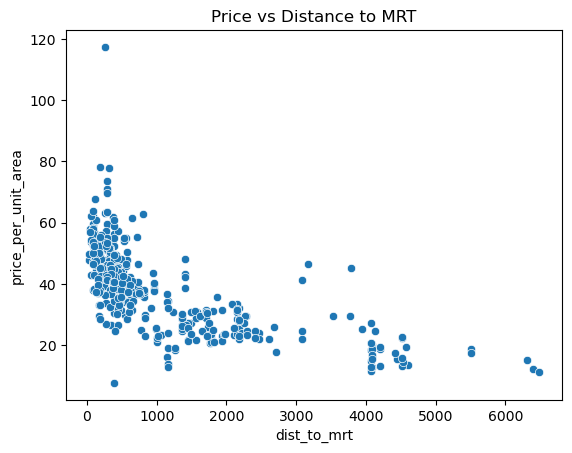

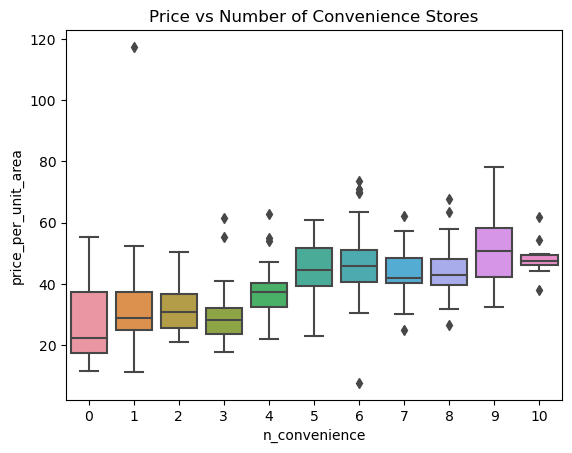

In [12]:
# Price vs House Age
sns.scatterplot(data=df, x="house_age", y="price_per_unit_area")
plt.title("Price vs House Age")
plt.show()

# Price vs Distance to MRT
sns.scatterplot(data=df, x="dist_to_mrt", y="price_per_unit_area")
plt.title("Price vs Distance to MRT")
plt.show()

# Price vs Number of Convenience Stores
sns.boxplot(data=df, x="n_convenience", y="price_per_unit_area")
plt.title("Price vs Number of Convenience Stores")
plt.show()


## Price vs. Distance to MRT
The scatter plot for "Price vs Distance to MRT" shows a very clear and strong negative correlation.

- The closer a property is to an MRT station, the higher its price per unit area tends to be.  
- There is a high concentration of high-priced properties within the first few hundred meters of an MRT station.  
- As the distance increases, the prices drop off quite dramatically.  
- Properties that are over 4,000 meters away generally have the lowest prices, often below $20,000 per unit area.  

The insight here is that proximity to public transit is a major driver of property value.

---

## Price vs. House Age
The scatter plot for "Price vs House Age" gives us a different perspective.

- Unlike the MRT chart, this one doesn’t show a strong linear correlation.  
- There’s no clear trend where older homes are consistently cheaper or more expensive.  
- A wide range of prices exists across all age groups.  
- The highest-priced outliers (~$120,000/unit area) are found in the newest homes (age 0).  
- Some older homes (ages 35–40) also show relatively high prices, confirming that other factors (location, condition, etc.) strongly influence value.  

Insight: House age has less direct impact on property value.

---

## Price vs. Number of Convenience Stores
The box plot for "Price vs Number of Convenience Stores" reveals a fascinating trend.

- A clear, direct relationship exists: as the number of convenience stores increases, so does the median price per unit area.  
- Lowest median prices occur where there are 0–3 convenience stores.  
- Median price steadily climbs, peaking at 9–10 convenience stores.  

The insight is that properties in more developed and convenient neighborhoods (with many shops) are more highly valued.


## Time Trends

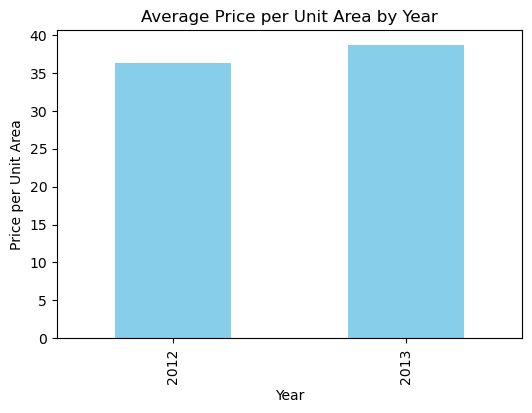

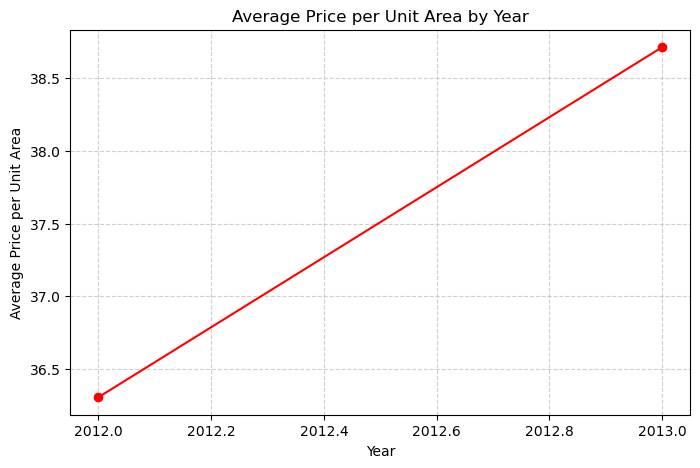

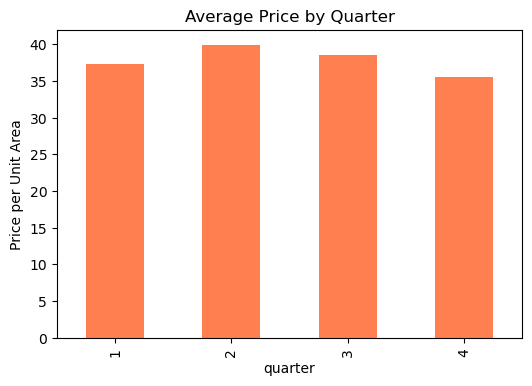

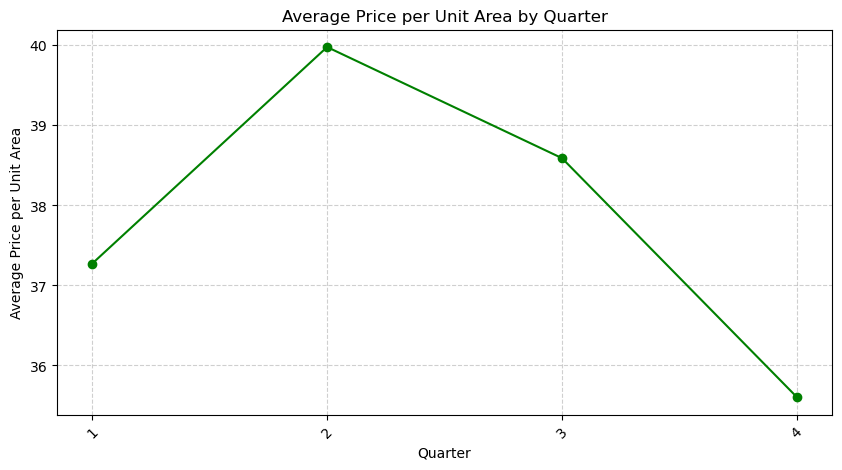

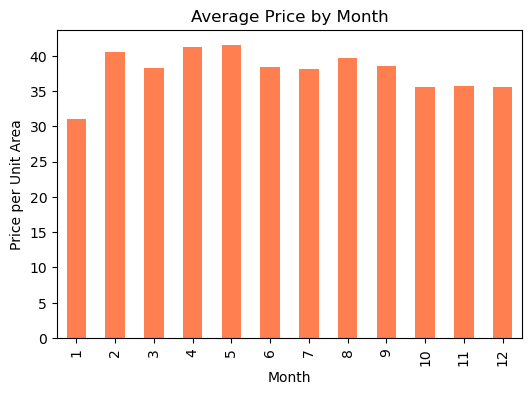

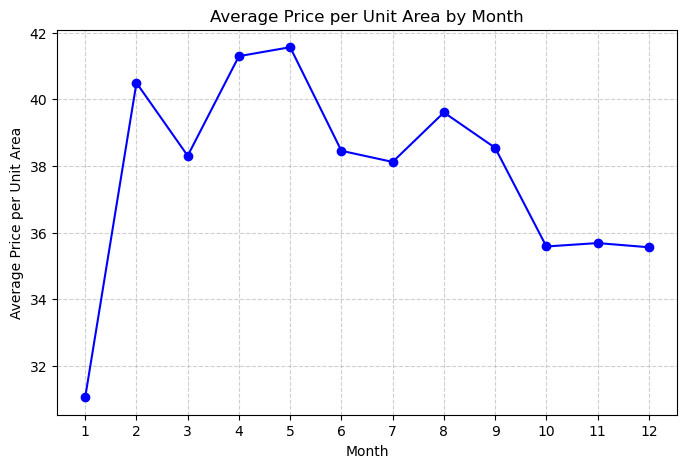

In [13]:
# Average price over years
avg_price_year = df.groupby("Year")["price_per_unit_area"].mean()

avg_price_year.plot(kind="bar", color="skyblue", figsize=(6,4))
plt.title("Average Price per Unit Area by Year")
plt.ylabel("Price per Unit Area")
plt.show()

# Yearly average price
avg_price_year = df.groupby("Year")["price_per_unit_area"].mean()

# trend line of yearly average price
plt.figure(figsize=(8,5))
plt.plot(avg_price_year.index, avg_price_year.values, marker='o', linestyle='-', color='red')
plt.title("Average Price per Unit Area by Year")
plt.xlabel("Year")
plt.ylabel("Average Price per Unit Area")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Quarterly trend
avg_price_quarter = df.groupby("quarter")["price_per_unit_area"].mean()

avg_price_quarter.plot(kind="bar", color="coral", figsize=(6,4))
plt.title("Average Price by Quarter")
plt.ylabel("Price per Unit Area")
plt.show()

# Trend line of quarterly average price
plt.figure(figsize=(10,5))
plt.plot(avg_price_quarter.index.astype(str), avg_price_quarter.values, marker='o', linestyle='-', color='green')
plt.title("Average Price per Unit Area by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Price per Unit Area")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Monthly trend
avg_price_month = df.groupby("Month")["price_per_unit_area"].mean()

avg_price_month.plot(kind="bar", color="coral", figsize=(6,4))
plt.title("Average Price by Month")
plt.ylabel("Price per Unit Area")
plt.show()

# average price per month trend line
plt.figure(figsize=(8,5))
plt.plot(avg_price_month.index, avg_price_month.values, marker='o', linestyle='-', color='blue')
plt.title("Average Price per Unit Area by Month")
plt.xlabel("Month")
plt.ylabel("Average Price per Unit Area")
plt.xticks(range(1, 13))  # Months 1-12
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Findings**

When combining the insights from all three time trend analyses, a clear story emerges about the trends in price per unit area.

**Positive Annual Growth:** Looking at the "Average Price per Unit Area by Year" chart, we can see a clear upward trend. The average price increased from approximately $36,000 per unit area in 2012 to about $39,000 per unit area in 2013, indicating a positive, though modest, annual appreciation in the market.

**Quarterly Fluctuations:** The "Average Price per Unit Area by Quarter" chart provides a more granular view of the yearly trend. Prices peaked in the second quarter, hitting a high of nearly $40,000 per unit area, and then began to decline steadily through the second half of the year, finishing at their lowest point in the fourth quarter. This suggests a seasonal pattern in the market.

**Monthly Volatility:** The "Average Price per Unit Area by Month" chart gives us the most detailed picture. We see significant month-to-month volatility. Prices jumped sharply from January to February, then settled down before rising again in the spring. The market was strongest in April and May, with prices reaching their peak. From June onwards, there was a general downward trend, with a slight bump in August and a final dip toward the end of the year. This confirms the quarterly pattern we observed and highlights specific periods of strength and weakness.

**Overall Insights**
Combining these findings, we can conclude that while the overall market experienced positive year-over-year growth, the price appreciation was not steady throughout the year. The market showed clear seasonal trends, with the first half of the year, particularly the spring months (April and May), being the strongest for prices. Prices then softened considerably in the second half of the year, especially in the fourth quarter. This suggests that buyers looking for better deals might have more leverage later in the year.


## Grouped Analysis

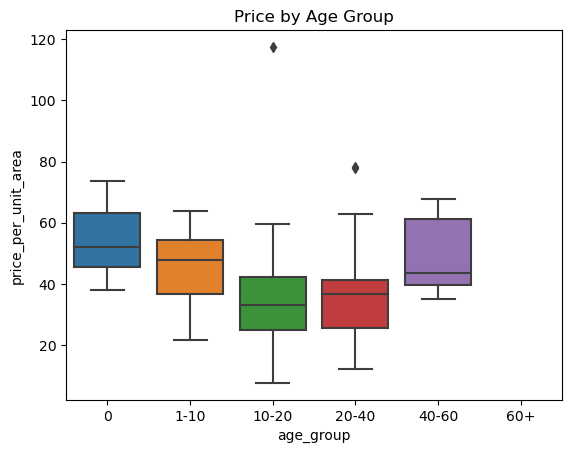

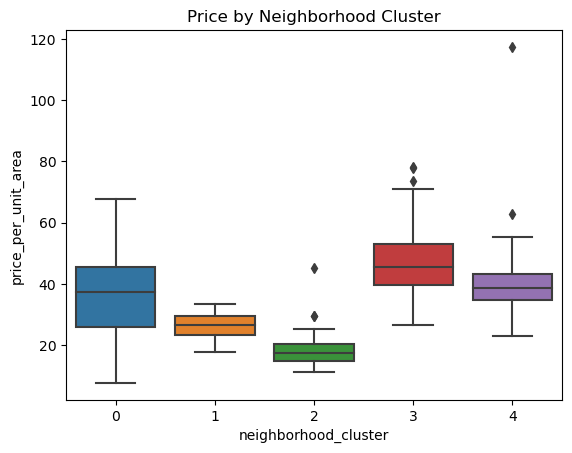

In [14]:
# Age group comparison
sns.boxplot(data=df, x="age_group", y="price_per_unit_area")
plt.title("Price by Age Group")
plt.show()

# Neighborhood clusters
sns.boxplot(data=df, x="neighborhood_cluster", y="price_per_unit_area")
plt.title("Price by Neighborhood Cluster")
plt.show()


### **Key Insights from the Box Plot**

When we look at the box plot of price by age group, we can see a few key things:

* **Homes in the '0' age group** (meaning newly built homes) have the highest median price, sitting around the mid-$50,000s per unit area. This isn't surprising, as new construction often commands a premium.
* The **'1-10' and '40-60' age groups** show the next highest median prices, both in the $40,000s. The '40-60' group is particularly interesting because it suggests these properties might be in desirable locations or have been well-maintained.
* The **lowest prices** are found in the **'10-20' and '20-40' age groups**, with medians in the low to mid-$30,000s. This could be due to a variety of factors, such as the need for updates or being in a less sought-after market.
* We're also seeing some **outliers** with very high prices, especially in the **'0' and '20-40' age groups**. This indicates a few properties that are priced significantly higher than the majority of homes in their age category.

In [15]:
df.columns

Index(['house_age', 'dist_to_mrt', 'n_convenience', 'latitude', 'longitude',
       'price_per_unit_area', 'Year', 'Month', 'transaction_date', 'quarter',
       'season', 'log_dist_to_mrt', 'log_price', 'age_group', 'dist_to_center',
       'neighborhood_cluster'],
      dtype='object')

In [22]:
df


,house_age,dist_to_mrt,n_convenience,latitude,longitude,price_per_unit_area,Year,Month,transaction_date,quarter,season,log_dist_to_mrt,log_price,age_group,dist_to_center,neighborhood_cluster,price_class
0,32.0,84.87882,10,24.98298,121.54024,37.9,2012,12,2012-12-01,4,1,4.452937,3.660994,20-40,6.095201,3,0
1,19.5,306.59470,9,24.98034,121.53951,42.2,2012,12,2012-12-01,4,1,5.728783,3.765840,10-20,6.391996,3,1
2,13.3,561.98450,5,24.98746,121.54391,47.3,2013,8,2013-08-01,3,3,6.333252,3.877432,10-20,5.491231,3,1
3,13.3,561.98450,5,24.98746,121.54391,54.8,2013,7,2013-07-01,3,3,6.333252,4.021774,10-20,5.491231,3,1
4,5.0,390.56840,5,24.97937,121.54245,43.1,2012,11,2012-11-01,4,4,5.970160,3.786460,1-10,6.376489,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,13.7,4082.01500,0,24.94155,121.50381,15.4,2013,1,2013-01-01,1,1,8.314591,2.797281,10-20,11.886364,2,0
410,5.6,90.45606,9,24.97433,121.54310,50.0,2012,9,2012-09-01,3,4,4.515859,3.931826,1-10,6.877876,3,1
411,18.8,390.96960,7,24.97923,121.53986,40.6,2013,4,2013-04-01,2,2,5.971184,3.728100,10-20,6.490290,3,1
412,8.1,104.81010,5,24.96674,121.54067,52.5,2013,1,2013-01-01,1,1,4.661646,3.979682,1-10,7.752763,0,1


## **MODEL TRAINING AND TESTING**

Mean Absolute Error: 3.8505161933448107
Root Mean Squared Error: 5.539849888356136
R² Score: 0.8170601840549715


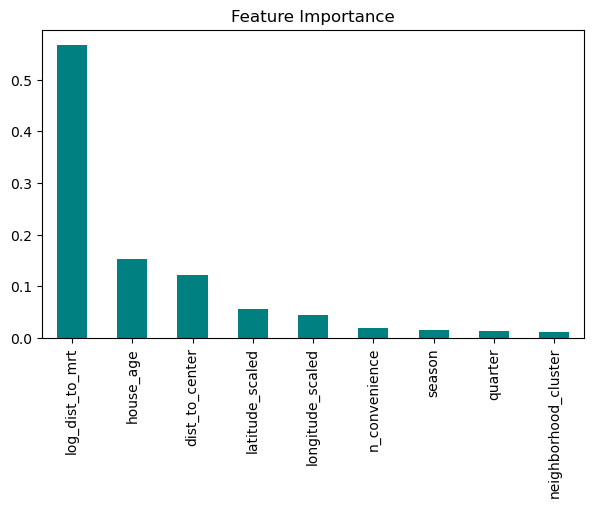

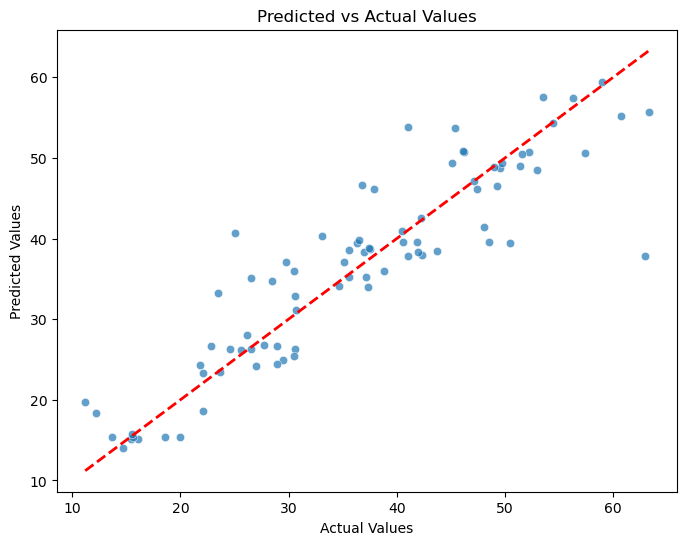

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


# 1. Handling outliers in the target (price_per_unit_area)

Q1 = df['price_per_unit_area'].quantile(0.25)
Q3 = df['price_per_unit_area'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Winsorize (cap extreme values instead of removing data)
df['price_per_unit_area_capped'] = df['price_per_unit_area'].clip(lower=lower_bound, upper=upper_bound)


# 2. Normalizing spatial features (latitude & longitude)

scaler = StandardScaler()
df[['latitude_scaled', 'longitude_scaled']] = scaler.fit_transform(df[['latitude', 'longitude']])


# 3. Defining Features and Target

X = df[[ 
    "house_age",
    "n_convenience",
    "dist_to_center",
    "latitude_scaled",   # use scaled
    "longitude_scaled",  # use scaled
    "log_dist_to_mrt",
    "quarter",
    "season",
    "neighborhood_cluster"
]]

y = df["price_per_unit_area_capped"]   # using capped target


# 4. Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 5. model training

model = RandomForestRegressor(random_state=42, n_estimators=200, max_depth=None)
model.fit(X_train, y_train)


# 6. Predictions

y_pred = model.predict(X_test)


# 7. Evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)


# 8. Feature importance

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind="bar", figsize=(7,4), color="teal")
plt.title("Feature Importance")
plt.show()


# 9. Predicted vs Actual plot

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")
plt.show()


Now below, I want to examine if it is possible that the perfomance of the random forest regressor may be somewhat improved so I am employing the use of grid search technique to see what hyperparameter values should best be used 

In [41]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["auto", "sqrt", "log2"]
}

# Random Forest
rf = RandomForestRegressor(random_state=42)

# Grid Search with CV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,            # 5-fold cross-validation
    n_jobs=-1,       # use all CPUs
    verbose=2,
    scoring="r2"     # optimize for R²
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Retrain with best params
best_model = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
Best CV Score: 0.7236597620604931
MAE: 3.7447981879432493
RMSE: 5.398590671484872
R²: 0.8262707104043931


From the Grid search, the best Parameters for model improvements will be 

'max_depth': None

'max_features': 'sqrt'

'min_samples_leaf': 2 

'min_samples_split': 2 

'n_estimators': 500

as these produced more optimal results

Mean Absolute Error: 3.7447981879432493
Root Mean Squared Error: 5.398590671484872
R² Score: 0.8262707104043931


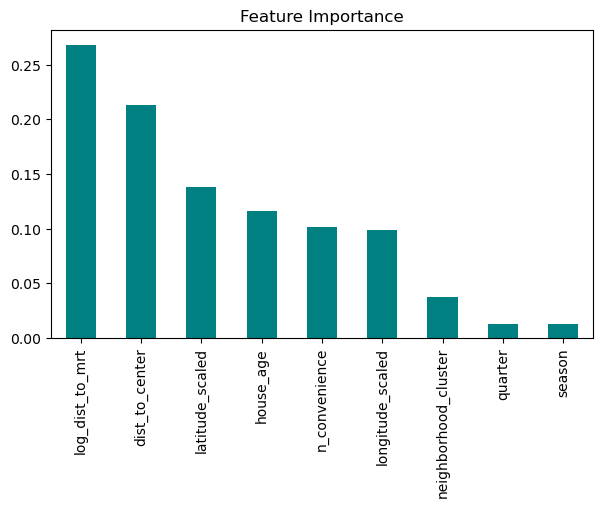

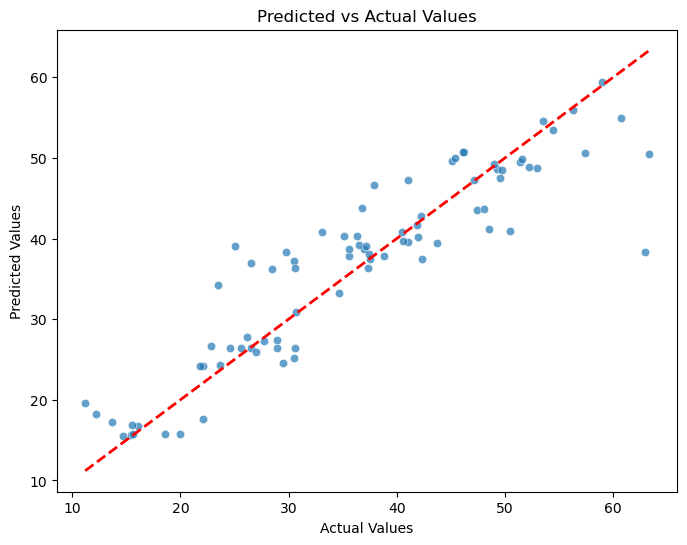

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np


# 1. Handling outliers in the target (price_per_unit_area)

Q1 = df['price_per_unit_area'].quantile(0.25)
Q3 = df['price_per_unit_area'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# capping extreme values instead of removing data
df['price_per_unit_area_capped'] = df['price_per_unit_area'].clip(lower=lower_bound, upper=upper_bound)


# 2. Normalizing spatial features (latitude & longitude)

scaler = StandardScaler()
df[['latitude_scaled', 'longitude_scaled']] = scaler.fit_transform(df[['latitude', 'longitude']])


# 3. Defining Features and Target

X = df[[ 
    "house_age",
    "n_convenience",
    "dist_to_center",
    "latitude_scaled",   # use scaled
    "longitude_scaled",  # use scaled
    "log_dist_to_mrt",
    "quarter",
    "season",
    "neighborhood_cluster"
]]

y = df["price_per_unit_area_capped"]   # use capped target


# 4. Train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 5. model training

# model with tuned hyperparameters
model = RandomForestRegressor(
    max_depth=None,
    max_features="sqrt",
    min_samples_leaf=2,
    min_samples_split=2,
    n_estimators=500,
    random_state=42
)

# model fitting
model.fit(X_train, y_train)


# 6. Predictions

y_pred = model.predict(X_test)


# 7. model evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)


# 8. Feature importance

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind="bar", figsize=(7,4), color="teal")
plt.title("Feature Importance")
plt.show()


# 9. Predicted vs Actual plot

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")
plt.show()
